## **Estudio de Ablación**

En este notebook llevamos a cabo el estudio de ablación de los modelos multimodales intra e inter-dominio seleccionados tras el ajuste de hiperparámetros: 

* **MODELO INTER-DOMINIO**:
    * **Corpus Global Unificado (MELD + IEMOCAP)**: 
        * Arquitectura de Fusión mediante Atención:
            - **Ventana de Vídeo**: 32 frames
            - **Ventana de Audio**: 7 segundos
            - **Ventana de Texto**: 32 tokens
            - **proj_dim**: 512 y **hidden_mlp**: 128 (Red Grande)
            - **Learning Rate**: 5e-05
            - **Dropout**: 0.3

* **MODELOS INTRA-DOMINIO**:
    * **Dataset MELD**:
        * Arquitectura de Fusión Tardía mediante Regresión Logística:
            - **Ventana de Vídeo**: 32 frames
            - **Ventana de Audio**: 7 segundos
            - **Ventana de Texto**: 32 tokens
            - **proj_dim**: 512 y **hidden_mlp**: 128 (Red Grande)
            - **Learning Rate**: 0.0001
            - **Dropout**: 0.5

    * **Dataset IEMOCAP**:
        * Arquitectura de Fusión Temprana:
            - **Ventana de Vídeo**: 32 frames
            - **Ventana de Audio**: 7 segundos
            - **Ventana de Texto**: 32 tokens
            - **proj_dim**: 512 y **hidden_mlp**: 128 (Red Grande)
            - **Learning Rate**: 0.0001
            - **Dropout**: 0.3


Con el análisis de interpretabilidad obtenemos la importancia asignada por el modelo a cada modalidad (lo que "dice" que hace el modelo), pero ahora con el estudio de ablación comprobamos realmente "qué hace" ante la ausencia de alguna o varias de las modalidades de entrada. 

Para los 3 modelos, se realiza lo mismo: **cargamos el modelo** ya entrenado y ajustado en su respectivo dataset, y lo que hacemos es, **con los datos de la partición de test de su dataset**, pasamos un tensor de ceros en lugar del vector de características para dicha modalidad o modalidades ("apagamos" la/s modalidad/es). 


In [11]:
# Cargamos las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os

-----

### **Modelo Global (Fusión mediante Atención)**

* **Sin vídeo**:

In [3]:
path_pesos = 'pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study video ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:19<00:00, 213.87it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.45 ms / muestra
ROC-AUC Score: 0.7783
F1 Macro: 0.5941
F1 Weighted: 0.6505
Accuracy (en %): 61.99%
Balanced Accuracy (en %): 69.06%


CompletedProcess(args='python evaluate.py --model_path pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --eval_dataset global --split test --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study video ', returncode=0)

* **Sin audio**:

In [4]:
path_pesos = 'pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study audio ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:19<00:00, 218.32it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.35 ms / muestra
ROC-AUC Score: 0.7811
F1 Macro: 0.6855
F1 Weighted: 0.7654
Accuracy (en %): 75.24%
Balanced Accuracy (en %): 71.55%


CompletedProcess(args='python evaluate.py --model_path pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --eval_dataset global --split test --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study audio ', returncode=0)

* **Sin texto**:

In [5]:
path_pesos = 'pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study texto ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:18<00:00, 224.40it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.23 ms / muestra
ROC-AUC Score: 0.4824
F1 Macro: 0.4368
F1 Weighted: 0.6773
Accuracy (en %): 77.54%
Balanced Accuracy (en %): 50.00%


CompletedProcess(args='python evaluate.py --model_path pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --eval_dataset global --split test --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study texto ', returncode=0)

Vemos que sin la modalidad textual, nos salta una advertencia de que el modelo no ha predicho una de las dos clases ni una sola vez y, observando el ROC-AUC por debajo de 0.5, nos está indicando que el modelo es incapaz de distinguir entre las dos clases. Se demuestra, por tanto, que el modelo ha colapsado para la tarea cuando no tiene la modalidad textual. 

* **Sin vídeo ni audio**:

In [6]:
path_pesos = 'pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study video audio ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:18<00:00, 228.19it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.20 ms / muestra
ROC-AUC Score: 0.7774
F1 Macro: 0.5913
F1 Weighted: 0.6466
Accuracy (en %): 61.59%
Balanced Accuracy (en %): 69.03%


CompletedProcess(args='python evaluate.py --model_path pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --eval_dataset global --split test --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study video audio ', returncode=0)

* **Sin vídeo ni texto**:

In [7]:
path_pesos = 'pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study video texto ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:19<00:00, 223.21it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.26 ms / muestra
ROC-AUC Score: 0.4623
F1 Macro: 0.4368
F1 Weighted: 0.6773
Accuracy (en %): 77.54%
Balanced Accuracy (en %): 50.00%


CompletedProcess(args='python evaluate.py --model_path pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --eval_dataset global --split test --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study video texto ', returncode=0)

De nuevo, sin texto, y esta vez sin vídeo, el modelo vuelve a colapsar. 

* **Sin audio ni texto**:

In [8]:
path_pesos = 'pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth'

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset global "
           f"--split test "
           f"--fusion attention "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study audio texto ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 4257/4257 [00:18<00:00, 224.14it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,928,514
Parámetros Entrenables: 8,928,514
Tiempo medio de Inferencia: 3.28 ms / muestra
ROC-AUC Score: 0.4985
F1 Macro: 0.4368
F1 Weighted: 0.6773
Accuracy (en %): 77.54%
Balanced Accuracy (en %): 50.00%


CompletedProcess(args='python evaluate.py --model_path pesos/inter_multimodal_ajuste/attention/global/pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3.pth --eval_dataset global --split test --fusion attention --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study audio texto ', returncode=0)

Sin texto de nuevo, y tampoco sin audio, el modelo se hunde en las métricas. Por tanto, podemos decir que el texto, tal y como nos indicaba el propio modelo global en el análisis de interpretabilidad, tiene el mayor peso en la toma de decisión, y cuando no lo tiene, el modelo es incapaz de distinguir muestras de estrés y no estrés. 

#### **Gráfica resumen**:

In [9]:
########### ---------- FUNCIÓN DE EXTRACCIÓN DE MÉTRICAS A PARTIR DEL REPORTE .txt ------------##############

def extraer_metricas_txt(ruta_txt):
    """
    Abre el reporte .txt y extrae el F1-Score Macro, Balanced Accuracy, el ROC-AUC y el Recall de la clase 'Estrés'
    """
    f1_macro = 0.0
    auc = 0.0
    ba = 0.0
    recall_estres = 0.0
    
    if not os.path.exists(ruta_txt):
        print(f"No se encuentra el archivo {ruta_txt}")
        return f1_macro, auc, recall_estres
        
    with open(ruta_txt, 'r', encoding='utf-8') as f:
        lineas = f.readlines()
        
    for linea in lineas:
        if "Balanced Accuracy" in linea:
            ba = float(linea.split(":")[1].strip())
        if "ROC-AUC:" in linea:
            auc = float(linea.split(":")[1].strip())
        elif "macro avg" in linea:
            # Ejemplo de línea que puede estar en el reporte: "macro avg    0.80      0.79      0.79       200"
            partes = linea.split()
            f1_macro = float(partes[4]) # El F1-Score está en la 5ª columna
        elif linea.strip().startswith("Estrés"):
            # Ejemplo de línea típica: "   Estrés       0.85      0.82      0.83       100"
            # partes[0]='Estrés', partes[1]=Precision, partes[2]=Recall
            partes = linea.split()
            recall_estres = float(partes[2])
            
    return f1_macro, ba, auc, recall_estres

,Escenario,F1-Macro,Balanced Accuracy,Recall Estrés,ROC-AUC
0,Completo,0.6891,0.7173,0.6454,0.7837
2,Sin Audio,0.6855,0.7155,0.6485,0.7811
1,Sin Vídeo,0.5941,0.6906,0.8190,0.7783
4,Solo Texto,0.5913,0.6903,0.8253,0.7774
3,Sin Texto,0.4368,0.5000,0.0000,0.4824
5,Solo Audio,0.4368,0.5000,0.0000,0.4623
6,Solo Vídeo,0.4368,0.5000,0.0000,0.4985


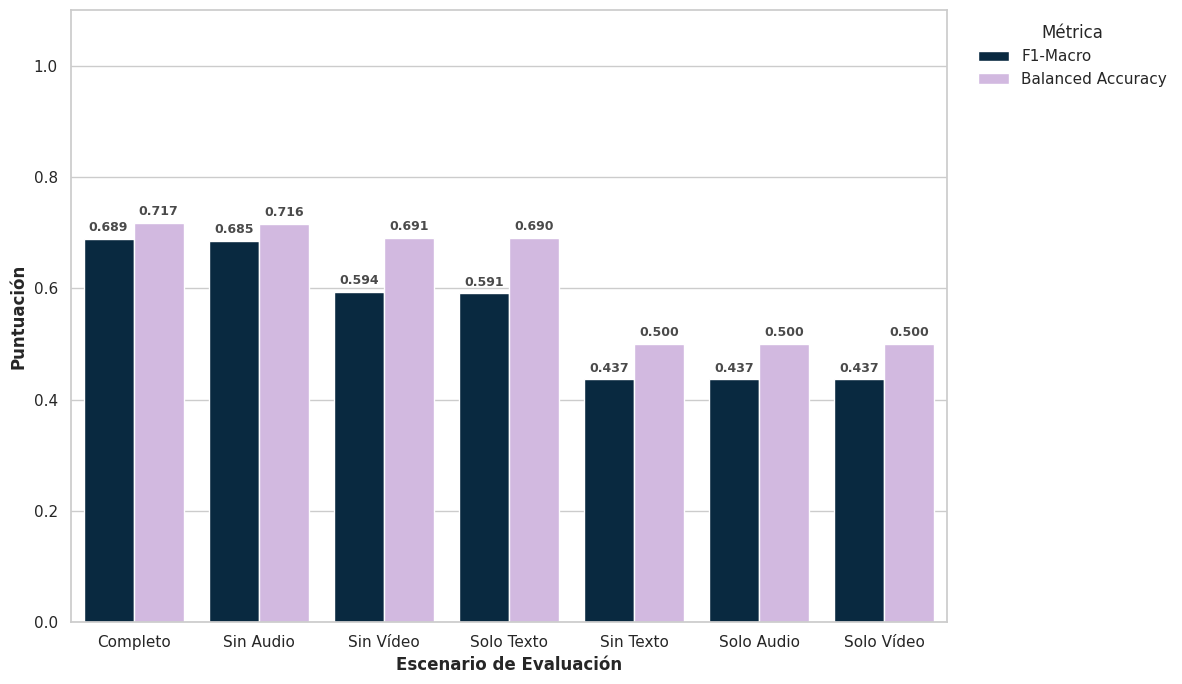

In [14]:
rutas_resultados = [
    {
        "Escenario": "Completo",
        "reporte": "resultados/inter_test/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_global_test.txt"
    },
    {
        "Escenario": "Sin Vídeo",
        "reporte": "resultados/estudio_ablacion/modelo_global/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_sin_video_global_test.txt"
    },
    {
        "Escenario": "Sin Audio",
        "reporte": "resultados/estudio_ablacion/modelo_global/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_sin_audio_global_test.txt"
    },
    {
        "Escenario": "Sin Texto",
        "reporte": "resultados/estudio_ablacion/modelo_global/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_sin_texto_global_test.txt"
    },
    {
        "Escenario": "Solo Texto",
        "reporte": "resultados/estudio_ablacion/modelo_global/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_sin_video_audio_global_test.txt"
    },
    {
        "Escenario": "Solo Audio",
        "reporte": "resultados/estudio_ablacion/modelo_global/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_sin_video_texto_global_test.txt"
    },
    {
        "Escenario": "Solo Vídeo",
        "reporte": "resultados/estudio_ablacion/modelo_global/reporte_pesos_modelo_estres_global_attention_resnet32_wav2vec7s_roberta32_p512_h128_lr5e-05_do0.3_sin_audio_texto_global_test.txt"
    }
]


datos_extraidos = []

for item in rutas_resultados:
    ruta_txt = item["reporte"]
    
    if os.path.exists(ruta_txt):
        f1, ba, auc, recall = extraer_metricas_txt(ruta_txt)
        
        datos_extraidos.append({
            "Escenario": item["Escenario"],
            "F1-Macro": f1,
            "Balanced Accuracy": ba,
            "Recall Estrés": recall,
            "ROC-AUC": auc
        })
    else:
        print(f"No se encontró el archivo reporte para {item['Escenario']} en: {ruta_txt}")

df_global = pd.DataFrame(datos_extraidos).sort_values(by='F1-Macro', ascending=False)


nombre_csv = 'tabla_resultados_ablacion_global_unificado.csv'
df_global.to_csv(nombre_csv, index=False)

display(df_global.style.background_gradient(
    subset=['F1-Macro', 'Balanced Accuracy', 'Recall Estrés', 'ROC-AUC'], 
    cmap='Blues'
).format(precision=4))


# Solo mostramos en la gráfica F1 y Balanced Accuracy
df_grafica = df_global[['Escenario', 'F1-Macro', 'Balanced Accuracy']]
df_melted = df_grafica.melt(id_vars='Escenario', var_name='Métrica', value_name='Puntuación')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))


colores = ['#002B49', '#D4B2E6']

barplot = sns.barplot(
    data=df_melted, 
    x='Escenario', 
    y='Puntuación', 
    hue='Métrica', 
    palette=colores 
)

plt.ylim(0, 1.1) # 
plt.ylabel('Puntuación', fontsize=12, fontweight='bold')
plt.xlabel('Escenario de Evaluación', fontsize=12, fontweight='bold')

for p in barplot.patches:
    altura = p.get_height()
    if pd.notnull(altura) and altura > 0:
        barplot.annotate(f"{altura:.3f}", 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', 
                    fontsize=9, color='#4a4a4a', fontweight='bold',
                    xytext=(0, 8), 
                    textcoords='offset points')

plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()

nombre_img = 'Fig_grafica_ablacion_global_unificado.png'
plt.savefig(nombre_img, dpi=300, bbox_inches='tight')

plt.show()

Podemos observar que el modelo, cuando dispone de todas las modalidades (completo), alcanza el mejor resultado en F1-Macro, Balanced Accuracy y ROC-AUC, beneficiándose por tanto de la multimodalidad, y es, en concreto, cuando le falta el texto (**vídeo/audio**, **solo audio**, **solo vídeo**) cuando el modelo colapsa y no sabe distiguir entre muestras de estrés y no estrés (etiquetando todas las muestras como **no estrés**). 

-----
### **Modelo Intra-dominio MELD (Fusión Tardía mediante aproximación Regresión Logística)**

* **Sin vídeo**:

In [15]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset MELD "
           f"--split test "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
           f"--ablation_study video ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 2608/2608 [00:11<00:00, 223.79it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.29 ms / muestra
ROC-AUC Score: 0.7940
F1 Macro: 0.5684
F1 Weighted: 0.6824
Accuracy (en %): 63.04%
Balanced Accuracy (en %): 71.25%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth --eval_dataset MELD --split test --fusion late --late_mode logistica --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 --ablation_study video ', returncode=0)

* **Sin audio**:

In [16]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset MELD "
           f"--split test "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
           f"--ablation_study audio ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 2608/2608 [00:11<00:00, 220.27it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.33 ms / muestra
ROC-AUC Score: 0.7940
F1 Macro: 0.6630
F1 Weighted: 0.8087
Accuracy (en %): 79.26%
Balanced Accuracy (en %): 70.10%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth --eval_dataset MELD --split test --fusion late --late_mode logistica --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 --ablation_study audio ', returncode=0)

* **Sin texto**:

In [17]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset MELD "
           f"--split test "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
           f"--ablation_study texto ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 2608/2608 [00:11<00:00, 222.73it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.30 ms / muestra
ROC-AUC Score: 0.5234
F1 Macro: 0.4703
F1 Weighted: 0.7812
Accuracy (en %): 84.59%
Balanced Accuracy (en %): 50.36%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth --eval_dataset MELD --split test --fusion late --late_mode logistica --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 --ablation_study texto ', returncode=0)

* **Sin vídeo ni audio**:

In [18]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset MELD "
           f"--split test "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
           f"--ablation_study video audio ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 2608/2608 [00:12<00:00, 210.84it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.49 ms / muestra
ROC-AUC Score: 0.7980
F1 Macro: 0.5632
F1 Weighted: 0.6748
Accuracy (en %): 62.19%
Balanced Accuracy (en %): 71.28%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth --eval_dataset MELD --split test --fusion late --late_mode logistica --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 --ablation_study video audio ', returncode=0)

* **Sin vídeo ni texto**:

In [19]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset MELD "
           f"--split test "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
           f"--ablation_study video texto ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 2608/2608 [00:11<00:00, 219.55it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.36 ms / muestra
ROC-AUC Score: 0.4919
F1 Macro: 0.1706
F1 Weighted: 0.1107
Accuracy (en %): 17.94%
Balanced Accuracy (en %): 48.95%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth --eval_dataset MELD --split test --fusion late --late_mode logistica --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 --ablation_study video texto ', returncode=0)

* **Sin audio ni texto**:

In [20]:
path_pesos = "pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset MELD "
           f"--split test "
           f"--fusion late "
           f"--late_mode logistica "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.5 "
           f"--ablation_study audio texto ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 2608/2608 [00:11<00:00, 220.06it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 8,994,823
Parámetros Entrenables: 8,994,823
Tiempo medio de Inferencia: 3.35 ms / muestra
ROC-AUC Score: 0.5343
F1 Macro: 0.4723
F1 Weighted: 0.7815
Accuracy (en %): 84.51%
Balanced Accuracy (en %): 50.42%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/late/logistica/MELD/pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5.pth --eval_dataset MELD --split test --fusion late --late_mode logistica --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.5 --ablation_study audio texto ', returncode=0)

#### **Gráfica resumen**:

,Escenario,F1-Macro,Balanced Accuracy,Recall Estrés,ROC-AUC
0,Completo,0.6664,0.7016,0.5646,0.7902
2,Sin Audio,0.6630,0.7010,0.5696,0.7940
1,Sin Vídeo,0.5684,0.7125,0.8304,0.7940
4,Solo Texto,0.5632,0.7128,0.8430,0.7980
6,Solo Vídeo,0.4723,0.5042,0.0152,0.5343
3,Sin Texto,0.4703,0.5036,0.0127,0.5234
5,Solo Audio,0.1706,0.4895,0.9342,0.4919


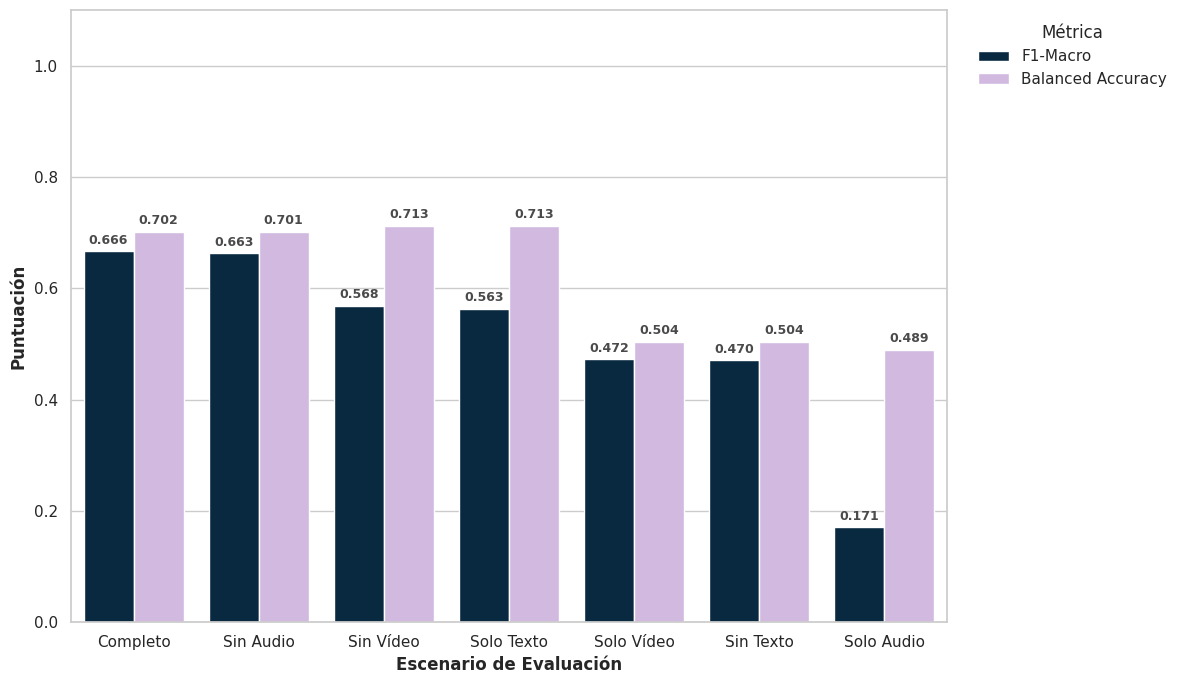

In [33]:
rutas_resultados = [
    {
        "Escenario": "Completo",
        "reporte": "resultados/intra_test/MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_MELD_test.txt"
    },
    {
        "Escenario": "Sin Vídeo",
        "reporte": "resultados/estudio_ablacion/modelo_MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_sin_video_MELD_test.txt"
    },
    {
        "Escenario": "Sin Audio",
        "reporte": "resultados/estudio_ablacion/modelo_MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_sin_audio_MELD_test.txt"
    },
    {
        "Escenario": "Sin Texto",
        "reporte": "resultados/estudio_ablacion/modelo_MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_sin_texto_MELD_test.txt"
    },
    {
        "Escenario": "Solo Texto",
        "reporte": "resultados/estudio_ablacion/modelo_MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_sin_video_audio_MELD_test.txt"
    },
    {
        "Escenario": "Solo Audio",
        "reporte": "resultados/estudio_ablacion/modelo_MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_sin_video_texto_MELD_test.txt"
    },
    {
        "Escenario": "Solo Vídeo",
        "reporte": "resultados/estudio_ablacion/modelo_MELD/reporte_pesos_modelo_estres_MELD_late_logistica_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.5_sin_audio_texto_MELD_test.txt"
    }
]


datos_extraidos = []

for item in rutas_resultados:
    ruta_txt = item["reporte"]
    
    if os.path.exists(ruta_txt):
        f1, ba, auc, recall = extraer_metricas_txt(ruta_txt)
        
        datos_extraidos.append({
            "Escenario": item["Escenario"],
            "F1-Macro": f1,
            "Balanced Accuracy": ba,
            "Recall Estrés": recall,
            "ROC-AUC": auc
        })
    else:
        print(f"No se encontró el archivo reporte para {item['Escenario']} en: {ruta_txt}")

df_meld = pd.DataFrame(datos_extraidos).sort_values(by='F1-Macro', ascending=False)


nombre_csv = 'tabla_resultados_ablacion_meld.csv'
df_meld.to_csv(nombre_csv, index=False)

display(df_meld.style.background_gradient(
    subset=['F1-Macro', 'Balanced Accuracy', 'Recall Estrés', 'ROC-AUC'], 
    cmap='Blues'
).format(precision=4))


# Solo mostramos en la gráfica F1 y Balanced Accuracy
df_grafica = df_meld[['Escenario', 'F1-Macro', 'Balanced Accuracy']]
df_melted = df_grafica.melt(id_vars='Escenario', var_name='Métrica', value_name='Puntuación')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))


colores = ['#002B49', '#D4B2E6']

barplot = sns.barplot(
    data=df_melted, 
    x='Escenario', 
    y='Puntuación', 
    hue='Métrica', 
    palette=colores 
)

plt.ylim(0, 1.1) # 
plt.ylabel('Puntuación', fontsize=12, fontweight='bold')
plt.xlabel('Escenario de Evaluación', fontsize=12, fontweight='bold')

for p in barplot.patches:
    altura = p.get_height()
    if pd.notnull(altura) and altura > 0:
        barplot.annotate(f"{altura:.3f}", 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', 
                    fontsize=9, color='#4a4a4a', fontweight='bold',
                    xytext=(0, 8), 
                    textcoords='offset points')

plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()

nombre_img = 'Fig_grafica_ablacion_meld.png'
plt.savefig(nombre_img, dpi=300, bbox_inches='tight')

plt.show()

De nuevo, principalmente en cuanto a la métrica de **F1-Score Macro**, es el modelo "completo" el que alcanza mayor rendimiento y, al igual que ocurría con el modelo entrenado sobre el corpus global unificado, sin texto, el modelo se hunde en todas las métricas, incapaz de distinguir correctamente entre muestras de estrés y no estrés. 

------
### **Modelo Intra-dominio IEMOCAP (Fusión Temprana)**

* **Sin vídeo**:

In [24]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset IEMOCAP "
           f"--split test "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study video ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 1649/1649 [00:08<00:00, 203.23it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.58 ms / muestra
ROC-AUC Score: 0.8113
F1 Macro: 0.2580
F1 Weighted: 0.1779
Accuracy (en %): 34.26%
Balanced Accuracy (en %): 50.18%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth --eval_dataset IEMOCAP --split test --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study video ', returncode=0)

* **Sin audio**:

In [25]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset IEMOCAP "
           f"--split test "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study audio ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 1649/1649 [00:07<00:00, 215.84it/s]


MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.37 ms / muestra
ROC-AUC Score: 0.7823
F1 Macro: 0.6738
F1 Weighted: 0.6899
Accuracy (en %): 68.16%
Balanced Accuracy (en %): 70.39%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth --eval_dataset IEMOCAP --split test --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study audio ', returncode=0)

* **Sin texto**:

In [26]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset IEMOCAP "
           f"--split test "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study texto ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 1649/1649 [00:07<00:00, 214.55it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.41 ms / muestra
ROC-AUC Score: 0.5788
F1 Macro: 0.3975
F1 Weighted: 0.5246
Accuracy (en %): 65.98%
Balanced Accuracy (en %): 50.00%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth --eval_dataset IEMOCAP --split test --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study texto ', returncode=0)

* **Sin vídeo ni audio**:

In [27]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset IEMOCAP "
           f"--split test "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study video audio ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 1649/1649 [00:07<00:00, 211.86it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.46 ms / muestra
ROC-AUC Score: 0.8102
F1 Macro: 0.2538
F1 Weighted: 0.1727
Accuracy (en %): 34.02%
Balanced Accuracy (en %): 50.00%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth --eval_dataset IEMOCAP --split test --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study video audio ', returncode=0)

* **Sin vídeo ni texto**:

In [28]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset IEMOCAP "
           f"--split test "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study video texto ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 1649/1649 [00:07<00:00, 213.56it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.43 ms / muestra
ROC-AUC Score: 0.5428
F1 Macro: 0.3975
F1 Weighted: 0.5246
Accuracy (en %): 65.98%
Balanced Accuracy (en %): 50.00%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth --eval_dataset IEMOCAP --split test --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study video texto ', returncode=0)

* **Sin audio ni texto:**

In [29]:
path_pesos = "pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth"

comando = (f"python evaluate.py "
           f"--model_path {path_pesos} "
           f"--eval_dataset IEMOCAP "
           f"--split test "
           f"--fusion early "
           f"--video resnet "
           f"--video_frames 32 "
           f"--audio wav2vec "
           f"--audio_len 7 "
           f"--text roberta32 "
           f"--proj_dim 512 "
           f"--hidden_mlp 128 "
           f"--dropout 0.3 "
           f"--ablation_study audio texto ")
                        
subprocess.run(comando, shell=True)

100%|██████████| 1649/1649 [00:07<00:00, 214.39it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", r

MÉTRICAS DEL MODELO EN TEST:
Parámetros Totales: 9,650,689
Parámetros Entrenables: 9,650,689
Tiempo medio de Inferencia: 3.39 ms / muestra
ROC-AUC Score: 0.5626
F1 Macro: 0.3975
F1 Weighted: 0.5246
Accuracy (en %): 65.98%
Balanced Accuracy (en %): 50.00%


CompletedProcess(args='python evaluate.py --model_path pesos/intra_ajuste/early/IEMOCAP/pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3.pth --eval_dataset IEMOCAP --split test --fusion early --video resnet --video_frames 32 --audio wav2vec --audio_len 7 --text roberta32 --proj_dim 512 --hidden_mlp 128 --dropout 0.3 --ablation_study audio texto ', returncode=0)

#### **Gráfica resumen**:

,Escenario,F1-Macro,Balanced Accuracy,Recall Estrés,ROC-AUC
0,Completo,0.6860,0.7102,0.7522,0.7877
2,Sin Audio,0.6738,0.7039,0.7736,0.7823
3,Sin Texto,0.3975,0.5000,0.0000,0.5788
6,Solo Vídeo,0.3975,0.5000,0.0000,0.5626
5,Solo Audio,0.3975,0.5000,0.0000,0.5428
1,Sin Vídeo,0.2580,0.5018,1.0000,0.8113
4,Solo Texto,0.2538,0.5000,1.0000,0.8102


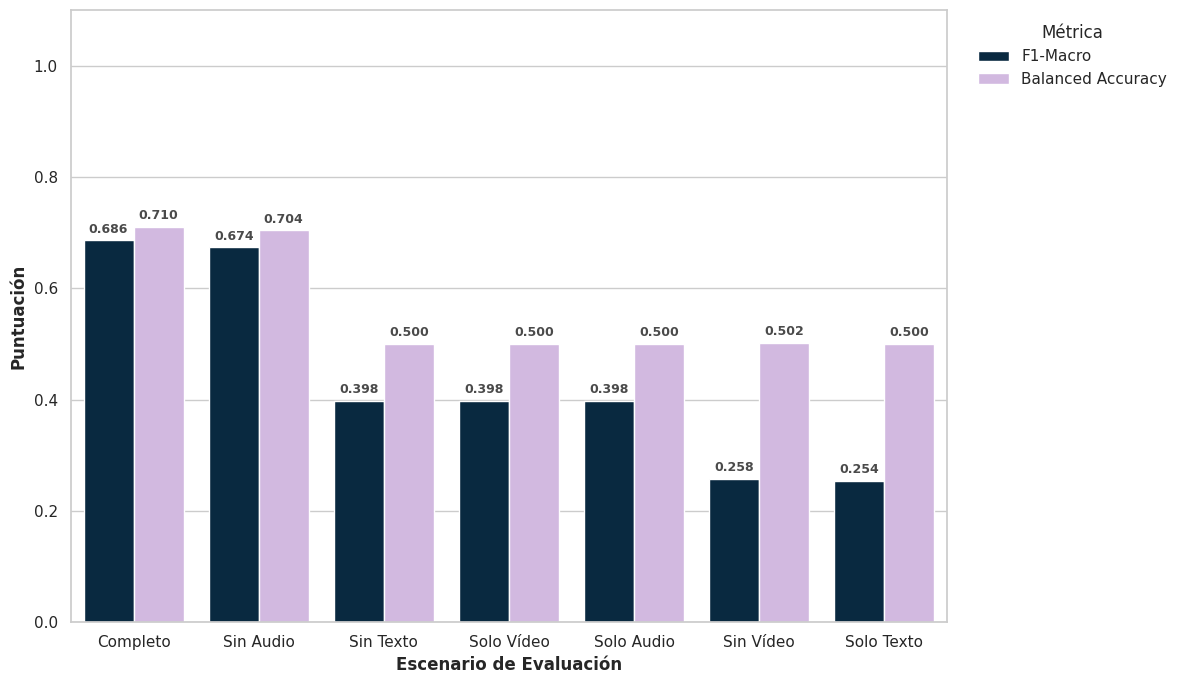

In [34]:
rutas_resultados = [
    {
        "Escenario": "Completo",
        "reporte": "resultados/intra_test/IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_IEMOCAP_test.txt"
    },
    {
        "Escenario": "Sin Vídeo",
        "reporte": "resultados/estudio_ablacion/modelo_IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_sin_video_IEMOCAP_test.txt"
    },
    {
        "Escenario": "Sin Audio",
        "reporte": "resultados/estudio_ablacion/modelo_IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_sin_audio_IEMOCAP_test.txt"
    },
    {
        "Escenario": "Sin Texto",
        "reporte": "resultados/estudio_ablacion/modelo_IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_sin_texto_IEMOCAP_test.txt"
    },
    {
        "Escenario": "Solo Texto",
        "reporte": "resultados/estudio_ablacion/modelo_IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_sin_video_audio_IEMOCAP_test.txt"
    },
    {
        "Escenario": "Solo Audio",
        "reporte": "resultados/estudio_ablacion/modelo_IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_sin_video_texto_IEMOCAP_test.txt"
    },
    {
        "Escenario": "Solo Vídeo",
        "reporte": "resultados/estudio_ablacion/modelo_IEMOCAP/reporte_pesos_modelo_estres_IEMOCAP_early_resnet32_wav2vec7s_roberta32_p512_h128_lr0.0001_do0.3_sin_audio_texto_IEMOCAP_test.txt"
    }
]


datos_extraidos = []

for item in rutas_resultados:
    ruta_txt = item["reporte"]
    
    if os.path.exists(ruta_txt):
        f1, ba, auc, recall = extraer_metricas_txt(ruta_txt)
        
        datos_extraidos.append({
            "Escenario": item["Escenario"],
            "F1-Macro": f1,
            "Balanced Accuracy": ba,
            "Recall Estrés": recall,
            "ROC-AUC": auc
        })
    else:
        print(f"No se encontró el archivo reporte para {item['Escenario']} en: {ruta_txt}")


df_iemocap = pd.DataFrame(datos_extraidos).sort_values(by='F1-Macro', ascending=False)


nombre_csv = 'tabla_resultados_ablacion_iemocap.csv'
df_iemocap.to_csv(nombre_csv, index=False)

display(df_iemocap.style.background_gradient(
    subset=['F1-Macro', 'Balanced Accuracy', 'Recall Estrés', 'ROC-AUC'], 
    cmap='Blues'
).format(precision=4))


# Solo mostramos en la gráfica F1 y Balanced Accuracy
df_grafica = df_iemocap[['Escenario', 'F1-Macro', 'Balanced Accuracy']]
df_melted = df_grafica.melt(id_vars='Escenario', var_name='Métrica', value_name='Puntuación')

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))


colores = ['#002B49', '#D4B2E6']

barplot = sns.barplot(
    data=df_melted, 
    x='Escenario', 
    y='Puntuación', 
    hue='Métrica', 
    palette=colores 
)

plt.ylim(0, 1.1) # 
plt.ylabel('Puntuación', fontsize=12, fontweight='bold')
plt.xlabel('Escenario de Evaluación', fontsize=12, fontweight='bold')

for p in barplot.patches:
    altura = p.get_height()
    if pd.notnull(altura) and altura > 0:
        barplot.annotate(f"{altura:.3f}", 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='center', 
                    fontsize=9, color='#4a4a4a', fontweight='bold',
                    xytext=(0, 8), 
                    textcoords='offset points')

plt.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()

nombre_img = 'Fig_grafica_ablacion_iemocap.png'
plt.savefig(nombre_img, dpi=300, bbox_inches='tight')

plt.show()

Vemos que, en línea con el resto de modelos, es el modelo completo el que alcanza el mayor rendimiento en las métricas, confirmando que todos los modelos, para estos datasets de MELD e IEMOCAP, se benefician de la información aportada por todas las modalidades, complementándose. Además, en este caso sorprende que el modelo de solo texto se haya desplomado, incapaz de identificar muestres de estrés y no estrés adecuadamente, indicando que, a diferencia del global unificado y MELD, en IEMOCAP el texto no es suficiente para la tarea y requiere de audio y vídeo. 